![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

En este proyecto podrán poner en práctica sus conocimientos sobre modelos predictivos basados en árboles y ensambles, y sobre la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 1: Predicción de popularidad en canción".

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 4. Sin embargo, es importante que avancen en la semana 3 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 4, y subir el archivo de predicciones a la competencia de Kaggle cuyo link estará disponible en la sección del Coursera del proyecto.

## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

## Ejemplo predicción conjunto de test para envío a Kaggle

En esta sección encontrarán el formato en el que deben guardar los resultados de la predicción para que puedan subirlos a la competencia en Kaggle.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación librerías
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from xgboost import XGBRegressor
from sklearn import metrics
import matplotlib.patches as mpatches

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from catboost import CatBoostRegressor, Pool

from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor

import joblib
pd.set_option('display.max_columns', None)

In [3]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTest_Spotify.csv', index_col=0)

In [4]:
# Visualización datos de entrenamiento
dataTraining.head()

,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,0,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,211533,False,0.305,0.8490,9,-10.795,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,goth,22
1,1,5x59U89ZnjZXuNAAlc8X1u,Filippa Giordano,Filippa Giordano,"Addio del passato - From ""La traviata""",196000,False,0.287,0.1900,7,-12.030,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,opera,22
2,2,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,216506,False,0.583,0.5090,1,-9.661,1,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,3,idm,37
3,3,1cRfzLJapgtwJ61xszs37b,Franz Liszt;YUNDI,Relajación y siestas,"Liebeslied (Widmung), S. 566",218346,False,0.163,0.0368,8,-23.149,1,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3,classical,0
4,4,47d5lYjbiMy0EdMRV8lRou,Scooter,Scooter Forever,The Darkside,173160,False,0.647,0.9210,2,-7.294,1,0.1850,0.000939,0.371000,0.1310,0.1710,137.981,4,techno,27


In [5]:
# Visualización datos de test
dataTesting.head()

,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,440247,False,0.369,0.598,7,-6.984,1,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4,world-music
1,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,93933,False,0.171,0.997,7,-3.586,1,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4,grindcore
2,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",213578,False,0.173,0.803,9,-10.071,0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3,iranian
3,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,151387,False,0.683,0.511,6,-5.598,1,0.0279,0.40600,0.000197,0.111,0.5980,109.991,3,rock
4,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,236293,False,0.555,0.941,9,-3.294,0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4,j-idol


# Preparación de los datos

# Pequeña Exploración

In [6]:
dataTraining.shape

(79800, 21)

In [7]:
dataTraining.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79800 entries, 0 to 79799
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        79800 non-null  int64  
 1   track_id          79800 non-null  object 
 2   artists           79800 non-null  object 
 3   album_name        79800 non-null  object 
 4   track_name        79800 non-null  object 
 5   duration_ms       79800 non-null  int64  
 6   explicit          79800 non-null  bool   
 7   danceability      79800 non-null  float64
 8   energy            79800 non-null  float64
 9   key               79800 non-null  int64  
 10  loudness          79800 non-null  float64
 11  mode              79800 non-null  int64  
 12  speechiness       79800 non-null  float64
 13  acousticness      79800 non-null  float64
 14  instrumentalness  79800 non-null  float64
 15  liveness          79800 non-null  float64
 16  valence           79800 non-null  float6

In [8]:
# Identificación de valores faltantes
valores_faltantes = dataTraining.isnull().sum()
print(valores_faltantes)

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
popularity          0
dtype: int64


In [9]:
print(dataTraining.duplicated().sum())

0


In [10]:
print("Duplicados totales:", dataTraining.duplicated().sum())

Duplicados totales: 0


In [11]:
dataTraining[dataTraining.duplicated(keep=False)].sort_values('track_name')

,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity


In [12]:
print(dataTraining.nunique())

Unnamed: 0          79800
track_id            66720
artists             25775
album_name          37315
track_name          55767
duration_ms         40712
explicit                2
danceability         1120
energy               1932
key                    12
loudness            17562
mode                    2
speechiness          1454
acousticness         4856
instrumentalness     5252
liveness             1706
valence              1737
tempo               37292
time_signature          5
track_genre           114
popularity            101
dtype: int64


In [13]:
dataTraining.describe()

,Unnamed: 0,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,popularity
count,79800.000000,7.980000e+04,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000
mean,39899.500000,2.279022e+05,0.567318,0.641529,5.307043,-8.263741,0.637732,0.084750,0.314979,0.157319,0.213313,0.474267,122.076559,3.902556,33.265301
std,23036.420078,1.050599e+05,0.173110,0.251441,3.562186,5.035504,0.480659,0.105657,0.332512,0.310792,0.190075,0.259010,29.941937,0.434284,22.330871
min,0.000000,1.338600e+04,0.000000,0.000019,0.000000,-49.307000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19949.750000,1.744360e+05,0.456000,0.472000,2.000000,-10.006000,0.000000,0.035900,0.017000,0.000000,0.097900,0.261000,99.081250,4.000000,17.000000
50%,39899.500000,2.128130e+05,0.581000,0.685000,5.000000,-7.012000,1.000000,0.049000,0.169000,0.000041,0.132000,0.464000,122.009000,4.000000,35.000000
75%,59849.250000,2.614260e+05,0.695000,0.854000,8.000000,-5.000000,1.000000,0.084500,0.598000,0.050500,0.273000,0.684000,140.054000,4.000000,50.000000
max,79799.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,222.605000,5.000000,100.000000


## Graficos

### Continuas

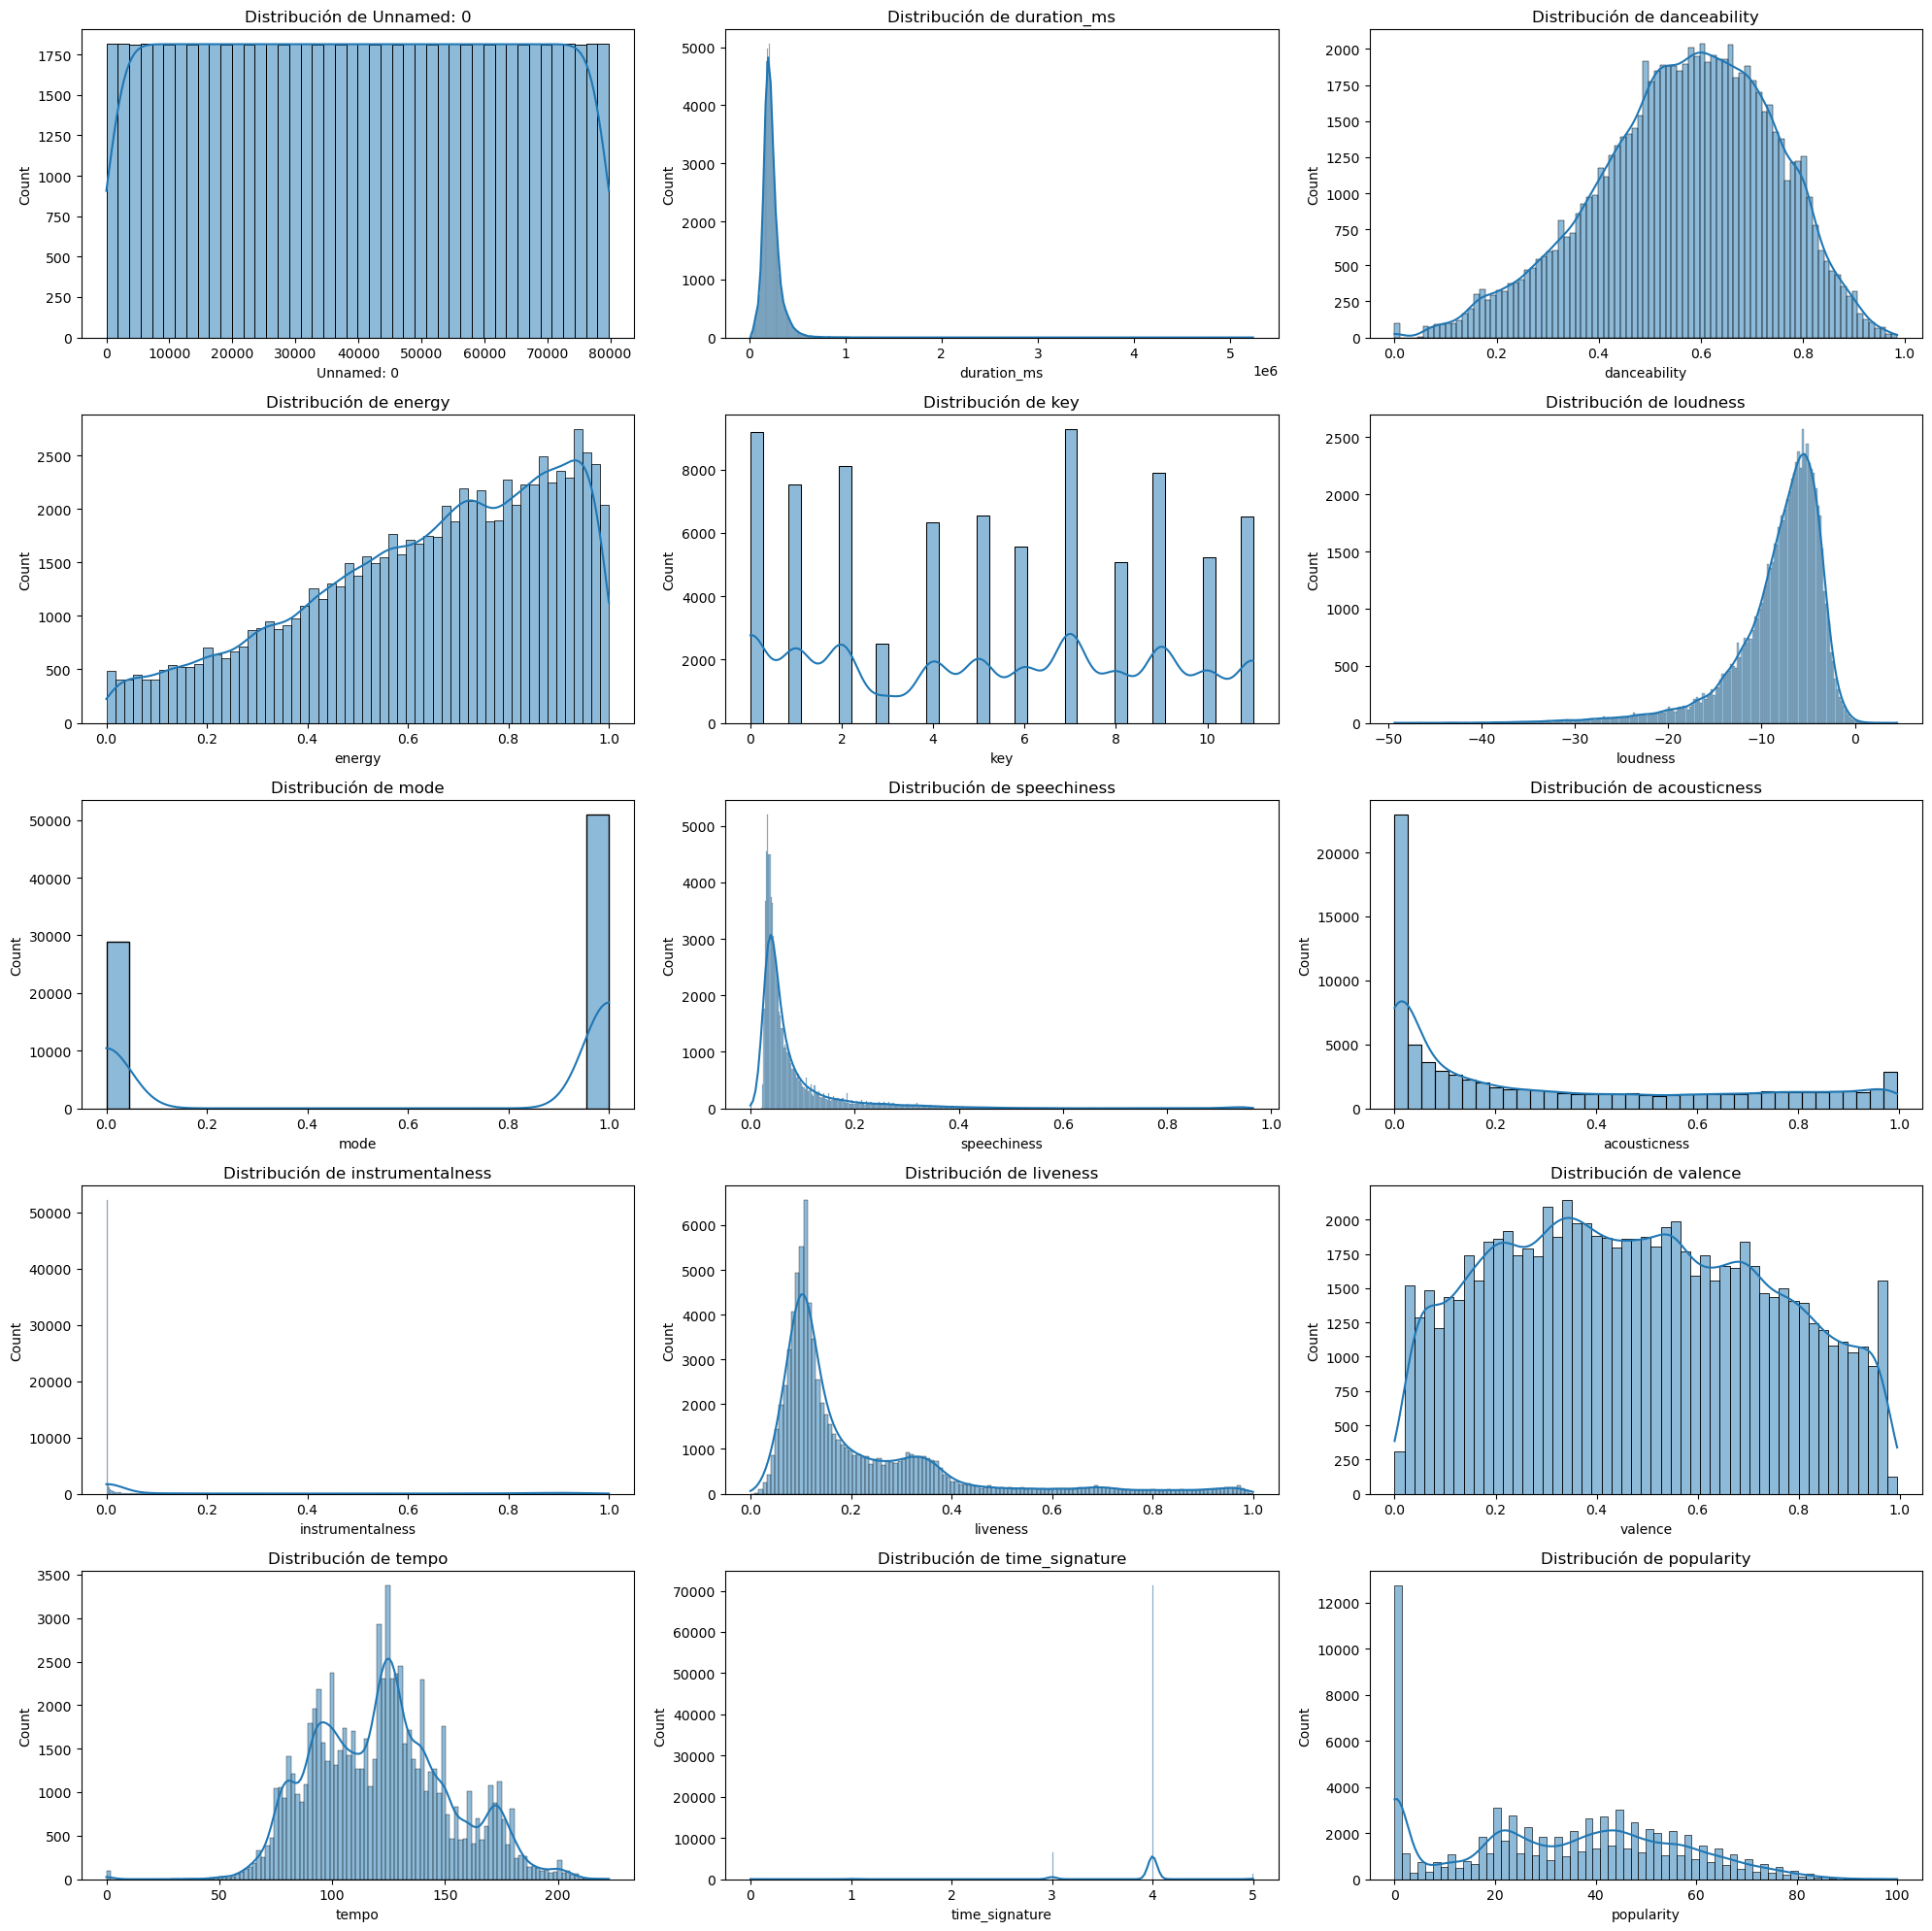

In [14]:

cols = [c for c in dataTraining.select_dtypes(include='number').columns]
        # if not c.startswith('track_genre_')
        # and not c.startswith('key')
        # and not c.startswith('time_signature')]

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(data=dataTraining, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


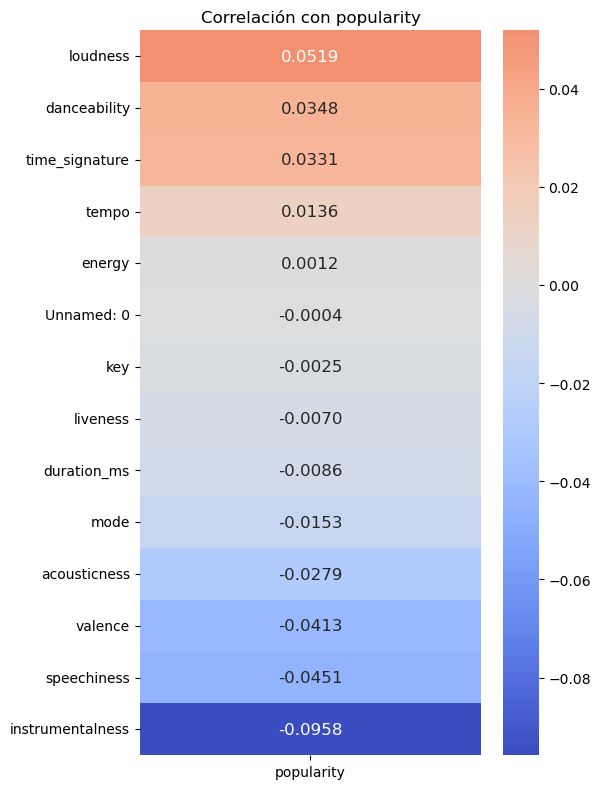

In [15]:
num_cols = [c for c in dataTraining.select_dtypes(include='number').columns]

corr_target = dataTraining[num_cols].corr()[['popularity']].drop('popularity')
corr_target = corr_target.sort_values('popularity', ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(corr_target, annot=True, fmt='.4f', cmap='coolwarm',
            annot_kws={'size': 12}, center=0)
plt.title('Correlación con popularity')
plt.tight_layout()
plt.show()

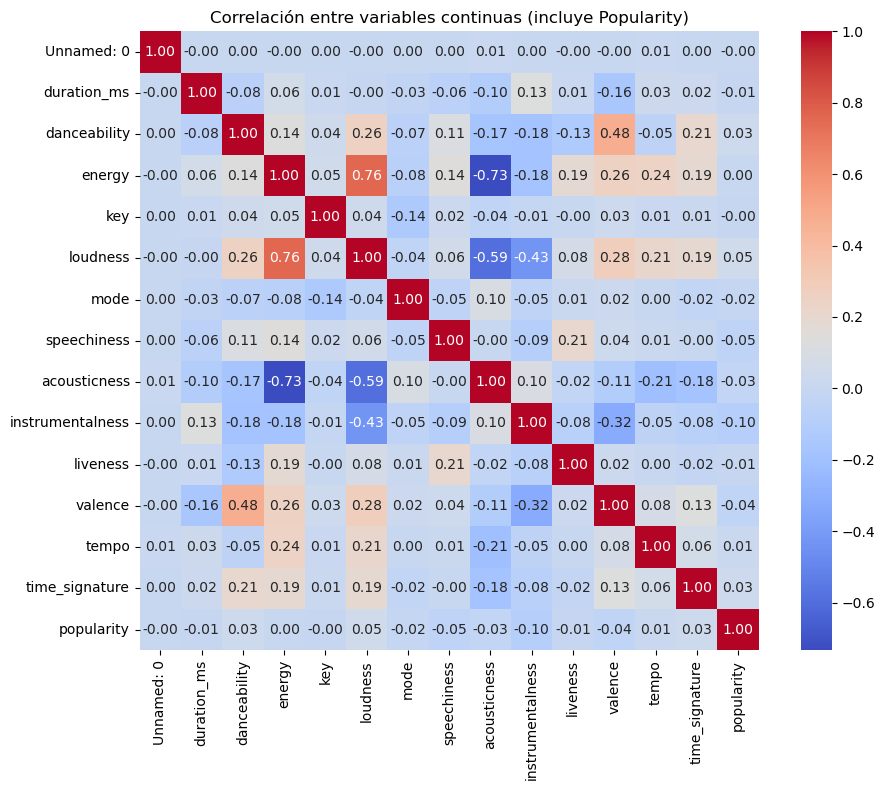

In [16]:
df_continuas = dataTraining[num_cols]
correlation_matrix = df_continuas.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlación entre variables continuas (incluye Popularity)')
plt.tight_layout()
plt.show()

### Binarias

In [17]:
variables_binarias_o_ordinales = [
    'explicit',     # booleana (0/1)
    'key',          # 12 valores → notas musicales
    'mode',         # 0 o 1 → menor/mayor
    'time_signature'  # de 3 a 7
]

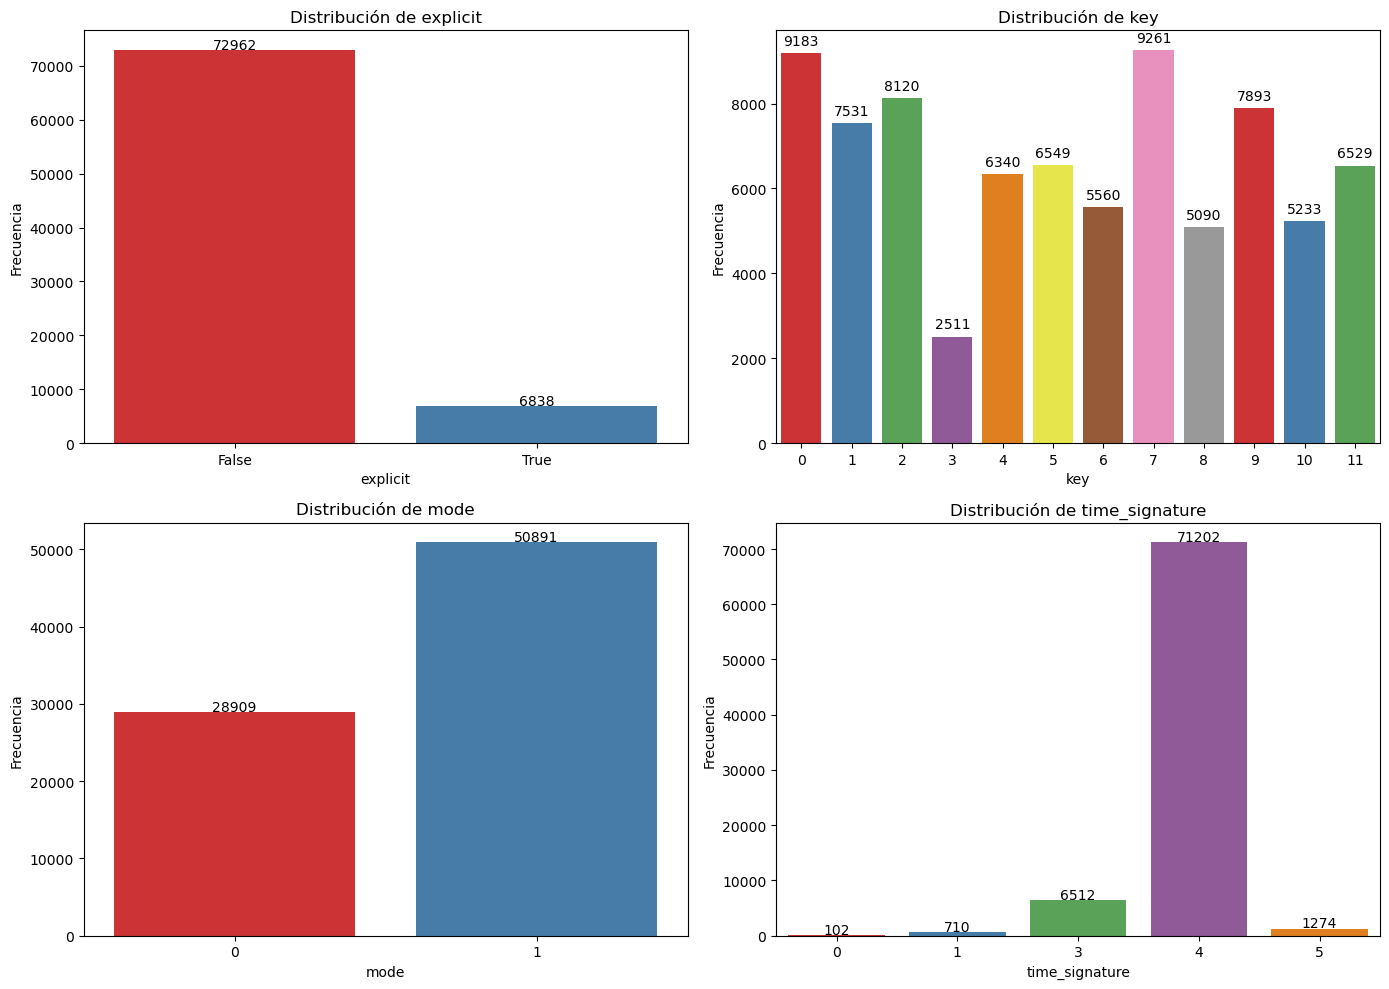

In [18]:
plt.figure(figsize=(14, 10))

for i, col in enumerate(variables_binarias_o_ordinales):
    plt.subplot(2, 2, i + 1)
    ax = sns.countplot(data=dataTraining, x=col, palette='Set1')
    
    # Agregar etiquetas de conteo sobre las barras
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2., height + 200, int(height), ha="center", fontsize=10)
    
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Categoricas

In [19]:
# Columnas de tipo object (strings)
cat_cols = dataTraining.select_dtypes(include='object').columns.tolist()
print(cat_cols)


['track_id', 'artists', 'album_name', 'track_name', 'track_genre']


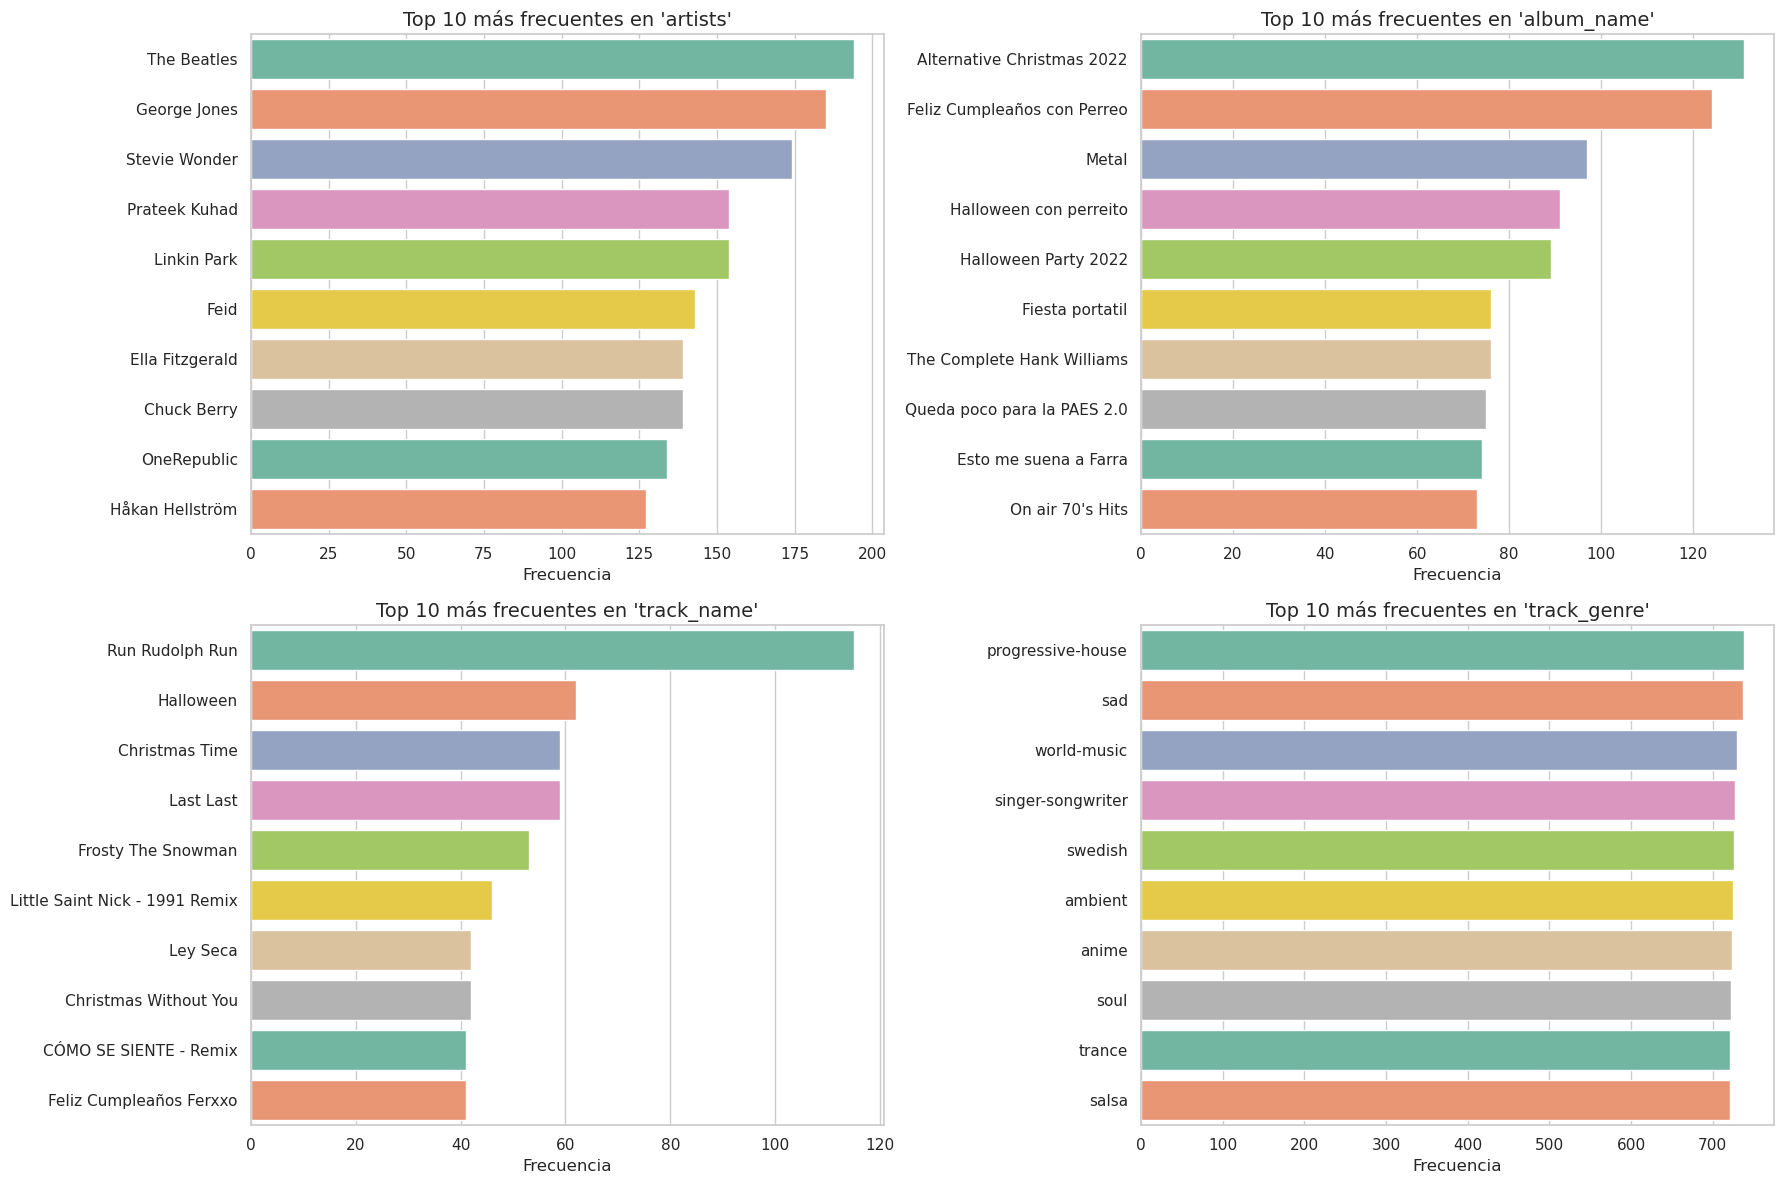

In [20]:
cat_cols_A = ['artists', 'album_name', 'track_name', 'track_genre']
top_n = 10
sns.set(style='whitegrid')
palette = sns.color_palette('Set2', top_n)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
axes = axes.flatten()
for i, var in enumerate(cat_cols_A):
    top_values = dataTraining[var].value_counts().nlargest(top_n)
    sns.barplot(x=top_values.values, y=top_values.index, ax=axes[i], palette=palette)
    axes[i].set_title(f"Top {top_n} más frecuentes en '{var}'", fontsize=14)
    axes[i].set_xlabel("Frecuencia")
    axes[i].set_ylabel("")
plt.tight_layout()
plt.show()

# Modelo

## Variables

In [21]:
dataTraining.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79800 entries, 0 to 79799
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        79800 non-null  int64  
 1   track_id          79800 non-null  object 
 2   artists           79800 non-null  object 
 3   album_name        79800 non-null  object 
 4   track_name        79800 non-null  object 
 5   duration_ms       79800 non-null  int64  
 6   explicit          79800 non-null  bool   
 7   danceability      79800 non-null  float64
 8   energy            79800 non-null  float64
 9   key               79800 non-null  int64  
 10  loudness          79800 non-null  float64
 11  mode              79800 non-null  int64  
 12  speechiness       79800 non-null  float64
 13  acousticness      79800 non-null  float64
 14  instrumentalness  79800 non-null  float64
 15  liveness          79800 non-null  float64
 16  valence           79800 non-null  float6

In [22]:
# Variables continuas (numéricas con muchos valores únicos)
continuas = [c for c in dataTraining.select_dtypes(include='number').columns
             if dataTraining[c].nunique() > 12]

# Variables binarias (exactamente 2 valores únicos)
binarias = [c for c in dataTraining.columns
            if dataTraining[c].nunique() == 2]

# Variables categóricas (object o numéricas con pocos valores únicos, excluyendo binarias)
categoricas = [c for c in dataTraining.columns
               if (dataTraining[c].dtype == 'object' or dataTraining[c].nunique() <= 12)
               and dataTraining[c].nunique() > 2]

print("Continuas:   ", continuas)
print("Binarias:    ", binarias)
print("Categóricas: ", categoricas)


Continuas:    ['Unnamed: 0', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'popularity']
Binarias:     ['explicit', 'mode']
Categóricas:  ['track_id', 'artists', 'album_name', 'track_name', 'key', 'time_signature', 'track_genre']


In [23]:
v_continuas = ['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

v_bina_o_ordin = ['explicit', 'key', 'mode', 'time_signature']

v_cat = ['album_name', 'artists', 'track_name', 'track_genre']

target = 'popularity'

In [24]:
df = dataTraining.copy()

In [25]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [26]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,0,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,211533,0,0.305,0.8490,9,-10.795,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,goth,22
1,1,5x59U89ZnjZXuNAAlc8X1u,Filippa Giordano,Filippa Giordano,"Addio del passato - From ""La traviata""",196000,0,0.287,0.1900,7,-12.030,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,opera,22
2,2,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,216506,0,0.583,0.5090,1,-9.661,1,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,3,idm,37
3,3,1cRfzLJapgtwJ61xszs37b,Franz Liszt;YUNDI,Relajación y siestas,"Liebeslied (Widmung), S. 566",218346,0,0.163,0.0368,8,-23.149,1,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3,classical,0
4,4,47d5lYjbiMy0EdMRV8lRou,Scooter,Scooter Forever,The Darkside,173160,0,0.647,0.9210,2,-7.294,1,0.1850,0.000939,0.371000,0.1310,0.1710,137.981,4,techno,27


In [27]:
X = df[v_continuas + v_bina_o_ordin + v_cat].copy()
y = df[target].copy()

In [28]:
# Frequency encoding
for col in v_cat:
    freq_map = X[col].value_counts(normalize=True).to_dict()
    X[col + '_freq'] = X[col].map(freq_map)
X.drop(columns=v_cat, inplace=True)
features_finales = v_continuas + v_bina_o_ordin + [col + '_freq' for col in v_cat]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

## Bagging con librería

In [30]:
# Modelo
bagreg = BaggingRegressor(DecisionTreeRegressor(max_features='log2'),
                          n_estimators=10, bootstrap=True, oob_score=True, random_state=1)

bagreg.fit(X_train, y_train)
y_pred_b = bagreg.predict(X_test)

# Métricas
mse_b  = mean_squared_error(y_test, y_pred_b)
rmse_b = np.sqrt(mse_b)
mae_b  = mean_absolute_error(y_test, y_pred_b)
r2_b   = r2_score(y_test, y_pred_b)
oob_b  = bagreg.oob_score_

print(f"MSE:    {mse_b:.4f}")
print(f"RMSE:   {rmse_b:.4f}")
print(f"MAE:    {mae_b:.4f}")
print(f"R²:     {r2_b:.4f}")
print(f"OOB R²: {oob_b:.4f}")

MSE:    188.2697
RMSE:   13.7211
MAE:    9.9980
R²:     0.6186
OOB R²: 0.4782


## Random Forest

In [31]:
# Celda 4
rf = RandomForestRegressor(oob_score=True, random_state=1)

# rf = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=15,        
#     max_features='sqrt', 
#     n_jobs=-1,           
#     oob_score=True,
#     random_state=1
# )

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf

# Evaluación
mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"RMSE: {rmse_rf:.4f}")
print(f"R2:   {r2_rf:.4f}")
print(f"OOB R2: {rf.oob_score_}")  
print(f"MAE:  {mae_rf:.4f}") 

RMSE: 12.3085
R2:   0.6931
OOB R2: 0.686125326062923
MAE:  8.6798


## XGBoost

In [32]:
clf = XGBRegressor(random_state=1)
clf

# Entrenamiento (fit) y desempeño del modelo XGBRegressor
clf.fit(X_train, y_train)
y_pred_xgb = clf.predict(X_test)

# Evaluación
mse_xgb  = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)

print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²:   {r2_xgb:.4f}")
print(f"MAE:  {mae_xgb:.4f}")

RMSE: 13.3426
R²:   0.6394
MAE:  9.7812


## CatBoostRegressor

In [33]:
# === 1. Variables por tipo ===
variables_continuas = [
    'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]
variables_binarias_o_ordinales = ['explicit', 'key', 'mode', 'time_signature']
variables_categoricas = ['artists', 'album_name', 'track_name', 'track_genre']
target = 'popularity'

# === 2. Preprocesamiento mínimo ===
if df['explicit'].dtype == bool:
    df['explicit'] = df['explicit'].astype(int)

features = variables_continuas + variables_binarias_o_ordinales + variables_categoricas
X = df[features]
y = df[target]

# === 3. K-Fold Cross-Validation ===
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_list = []
rmse_list = []
r2_list = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    train_pool = Pool(X_train, y_train, cat_features=variables_categoricas)
    test_pool = Pool(X_test, y_test, cat_features=variables_categoricas)

    model = CatBoostRegressor(
        iterations=800,
        learning_rate=0.1,
        depth=8,
        l2_leaf_reg=7,
        eval_metric='RMSE',
        random_seed=42,
        verbose=False
    )

    model.fit(train_pool)
    y_pred = model.predict(X_test)

    mae_list.append(mean_absolute_error(y_test, y_pred))
    rmse_list.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_list.append(r2_score(y_test, y_pred))

# === 4. Resultados promedio ===
print(f"MAE Promedio:  {np.mean(mae_list):.2f} ± {np.std(mae_list):.2f}")
print(f"RMSE Promedio: {np.mean(rmse_list):.2f} ± {np.std(rmse_list):.2f}")
print(f"R² Promedio:   {np.mean(r2_list):.2f} ± {np.std(r2_list):.2f}")

MAE Promedio:  6.32 ± 0.03
RMSE Promedio: 9.10 ± 0.05
R² Promedio:   0.83 ± 0.00


## CatBoostRegressor Calibrado

In [34]:
# === Scorers personalizados ===
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
rmse_scorer = make_scorer(lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)), greater_is_better=False)
r2_scorer = make_scorer(r2_score)

# === Modelo base ===
cat_model = CatBoostRegressor(
    early_stopping_rounds=100,
    border_count=254,
    eval_metric='RMSE',
    random_seed=42,
    verbose=False
)

# === GridSearch reducido y rápido
param_grid = {
    'iterations': [300, 600, 800],
    'learning_rate': [0.03, 0.05],
    'depth': [8, 10],
    'l2_leaf_reg': [1, 3]
}

# === Ejecutar GridSearch (según RMSE)
grid = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    cv=3,
    scoring=rmse_scorer,
    n_jobs=-1
)

# === Entrenamiento con variables categóricas
grid.fit(X, y, cat_features=variables_categoricas)

# === Evaluación final sobre el mismo set (referencial)
best_model = grid.best_estimator_
y_pred = best_model.predict(X)

mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

# === Mostrar resultados
print("\n✅ Mejores hiperparámetros encontrados:")
print(grid.best_params_)
print(f"\nMAE total:  {mae:.2f}")
print(f"RMSE total: {rmse:.2f}")
print(f"R² total:   {r2:.2f}")


✅ Mejores hiperparámetros encontrados:
{'depth': 10, 'iterations': 800, 'l2_leaf_reg': 1, 'learning_rate': 0.05}

MAE total:  4.62
RMSE total: 6.46
R² total:   0.92


# Kaggle

In [35]:
import pandas as pd
from catboost import CatBoostRegressor, Pool

# === 1. Asegurar tipos correctos y limpiar NaNs ===

# explicit a bool
dataTraining['explicit'] = dataTraining['explicit'].astype(bool)
dataTesting['explicit'] = dataTesting['explicit'].astype(bool)

# Imputar NaNs en variables categóricas SOLO en dataTesting
dataTesting['artists'] = dataTesting['artists'].fillna('unknown_artist')
dataTesting['album_name'] = dataTesting['album_name'].fillna('unknown_album')
dataTesting['track_name'] = dataTesting['track_name'].fillna('unknown_track')

# === 2. Definir variables ===
variables_continuas = [
    'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]
variables_binarias_o_ordinales = ['explicit', 'key', 'mode', 'time_signature']
variables_categoricas = ['artists', 'album_name', 'track_name', 'track_genre']
features = variables_continuas + variables_binarias_o_ordinales + variables_categoricas
target = 'popularity'

# === 3. Entrenar modelo con TODO el dataTraining ===
train_pool = Pool(dataTraining[features], dataTraining[target], cat_features=variables_categoricas)

from catboost import CatBoostRegressor


model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.05,
    depth=10,
    l2_leaf_reg=1,
    early_stopping_rounds=100,
    border_count=254,
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)


model.fit(train_pool)

# === 4. Predecir sobre el dataTesting ===
test_pool = Pool(dataTesting[features], cat_features=variables_categoricas)
predicciones = model.predict(test_pool)

# === 5. Crear archivo de Kaggle ===
submission = pd.DataFrame({
    'ID': range(len(predicciones)),
    'Popularity': predicciones
})
submission.to_csv('submission.csv', index=False)

0:	learn: 21.6237219	total: 167ms	remaining: 4m 10s
100:	learn: 10.7241261	total: 13.9s	remaining: 3m 12s
200:	learn: 9.9778334	total: 28.3s	remaining: 3m 2s
300:	learn: 9.5199245	total: 45.7s	remaining: 3m 2s
400:	learn: 9.1272840	total: 1m 5s	remaining: 2m 58s
500:	learn: 8.8175406	total: 1m 25s	remaining: 2m 50s
600:	learn: 8.5510329	total: 1m 40s	remaining: 2m 30s
700:	learn: 8.3076981	total: 1m 57s	remaining: 2m 13s
800:	learn: 8.0755212	total: 2m 10s	remaining: 1m 54s
900:	learn: 7.8577729	total: 2m 24s	remaining: 1m 36s
1000:	learn: 7.6443734	total: 2m 38s	remaining: 1m 18s
1100:	learn: 7.4629994	total: 2m 56s	remaining: 1m 3s
1200:	learn: 7.2740583	total: 3m 11s	remaining: 47.6s
1300:	learn: 7.1047455	total: 3m 27s	remaining: 31.7s
1400:	learn: 6.9478207	total: 3m 41s	remaining: 15.6s
1499:	learn: 6.7893927	total: 3m 54s	remaining: 0us


# Guardando pkl

In [38]:
import joblib
joblib.dump(model, 'modelo_catboost.pkl')
print("Modelo guardado como modelo_catboost.pkl")

Modelo guardado como modelo_catboost.pkl


In [39]:
model.fit(train_pool)

# Guardar modelo para la API
import joblib
joblib.dump(model, 'modelo_catboost.pkl')

# Predecir sobre el dataTesting
test_pool = Pool(dataTesting[features], cat_features=variables_categoricas)
...


0:	learn: 21.6237219	total: 299ms	remaining: 7m 28s
100:	learn: 10.7241261	total: 10.2s	remaining: 2m 21s
200:	learn: 9.9778334	total: 22.6s	remaining: 2m 25s
300:	learn: 9.5199245	total: 36s	remaining: 2m 23s
400:	learn: 9.1272840	total: 48.9s	remaining: 2m 14s
500:	learn: 8.8175406	total: 1m 1s	remaining: 2m 2s
600:	learn: 8.5510329	total: 1m 14s	remaining: 1m 50s
700:	learn: 8.3076981	total: 1m 26s	remaining: 1m 38s
800:	learn: 8.0755212	total: 1m 40s	remaining: 1m 28s
900:	learn: 7.8577729	total: 1m 55s	remaining: 1m 16s
1000:	learn: 7.6443734	total: 2m 8s	remaining: 1m 3s
1100:	learn: 7.4629994	total: 2m 21s	remaining: 51.2s
1200:	learn: 7.2740583	total: 2m 34s	remaining: 38.5s
1300:	learn: 7.1047455	total: 2m 48s	remaining: 25.8s
1400:	learn: 6.9478207	total: 3m 1s	remaining: 12.9s
1499:	learn: 6.7893927	total: 3m 15s	remaining: 0us


Ellipsis

In [36]:
# Predicción del conjunto de test - acá se genera un número aleatorio como ejemplo
np.random.seed(42)
y_pred = pd.DataFrame(np.random.rand(dataTesting.shape[0]) * 100, index=dataTesting.index, columns=['Popularity'])

In [37]:
# Guardar predicciones en formato exigido en la competencia de kaggle
y_pred.to_csv('test_submission_file.csv', index_label='ID')
y_pred.head()

,Popularity
0,37.454012
1,95.071431
2,73.199394
3,59.865848
4,15.601864
